In [1]:
import pandas as pd
import pandas as pd
import spacy
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler

In [2]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

In [3]:
HC3 = pd.read_csv("HC3.csv")

In [4]:
HC3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315000 entries, 0 to 314999
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   text        315000 non-null  object
 1   label       315000 non-null  object
 2   question    315000 non-null  object
 3   source      315000 non-null  object
 4   word_count  315000 non-null  int64 
 5   char_count  315000 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 14.4+ MB


In [5]:
HC3 = HC3.drop(columns=['char_count'])
HC3 = HC3.drop(columns=['word_count'])
HC3 = HC3.drop(columns=['source'])
HC3 = HC3.drop(columns=['question'])

In [6]:
HC3.head()

,text,label
0,If the Earth were to suddenly start spinning i...,ai
1,""" Processed "" food means the food has undergon...",human
2,"No, the baby will not look exactly like either...",ai
3,The chain rule . When you write sin^2 x ( a co...,human
4,Almost ALL helium on Earth came from a single ...,human


In [7]:
HC3.value_counts("label")

label
ai        105042
reborn    105000
human     104958
Name: count, dtype: int64

In [8]:
HC3.value_counts("text")

text
Disney is a very big company that owns many different things, including video game characters. When they make a movie like Wreck-It Ralph, they can use characters that they own in the movie. They also have the power to ask other companies if they can use their characters in the movie, and sometimes those companies say yes because it is a good way for them to promote their characters and make more money. In the case of Wreck-It Ralph, Disney was able to use a lot of different video game characters because they asked the companies that owned those characters and were able to come to agreements to use them in the movie.                                                                                                                                                                                                                                                                                                                                                                                   

In [9]:
HC3.duplicated().sum()

np.int64(219212)

In [10]:
HC3.drop_duplicates(inplace=True)

In [11]:
HC3['label'].value_counts()

label
reborn    42157
human     31359
ai        22272
Name: count, dtype: int64

In [12]:
HC3.value_counts("text")

text
안녕하세요 ! In Korean , many words sound the same . Actually , most verbs have very similar sounds due to the conjunctions having similar endings ; however , in lyrical form , Korean is not as challenging as you may think . The Korean language is very reliant on particles and conjugated words creating context . So if a few words sound similar , you intuitively connect the particles and conjunction and it makes sense . Also , popular culture has created words in Korean to help distinguish context . For instance , a word to say " you " is " 네 " which sounds like " neh " while the word to say " My " can be " 내 " which sounds like " Neh " so to avoid confusion , " You " becomes " 니 " or " Nee " and My is stressed more as " Nay " or " 내 " Thus when singing " I love you , " you sing 니가 사랑해 ( 사랑해 = love ) and no one thinks you love something you own . They know that you are referring to the person you are speaking to .                                                                          

In [13]:
HC3 = HC3[HC3['label'].isin(['human', 'ai'])].copy()
HC3['label'] = HC3['label'].map({'human': 0, 'ai': 1})

print(HC3['label'].value_counts())

label
0    31359
1    22272
Name: count, dtype: int64


In [14]:
cleaned_texts = []
verb_density = []
adj_density = []
pron_density = []

for doc in nlp.pipe(HC3['text'], batch_size=2000):

    verbs_count = 0
    adjectives_count = 0
    pronouns_count = 0
    valid_tokens = []
    
    for token in doc:
        if token.pos_ == "VERB":
            verbs_count += 1
        elif token.pos_ == "ADJ":
            adjectives_count += 1
        elif token.pos_ == "PRON":
            pronouns_count += 1

        if not token.is_stop and not token.is_punct and not token.like_num and token.is_alpha:
            valid_tokens.append(token.lemma_.lower())

    total_words = len(doc)

    cleaned_texts.append(" ".join(valid_tokens))
    verb_density.append(verbs_count / total_words)
    adj_density.append(adjectives_count / total_words)
    pron_density.append(pronouns_count / total_words)

In [15]:
HC3['clean_text'] = cleaned_texts
HC3['verb_density'] = verb_density
HC3['adj_density'] = adj_density
HC3['pron_density'] = pron_density

HC3_2 = HC3[HC3['clean_text'].str.strip().astype(bool)]

HC3_2.reset_index(drop=True, inplace=True)

HC3_2.head(10)

,text,label,clean_text,verb_density,adj_density,pron_density
0,If the Earth were to suddenly start spinning i...,1,earth suddenly start spin opposite direction d...,0.082090,0.059701,0.018657
1,""" Processed "" food means the food has undergon...",0,processed food mean food undergo mechanical ch...,0.147368,0.063158,0.042105
2,"No, the baby will not look exactly like either...",1,baby look exactly like twin inherit combinatio...,0.073684,0.073684,0.073684
3,The chain rule . When you write sin^2 x ( a co...,0,chain rule write x convenient notation sin der...,0.021390,0.064171,0.053476
4,Almost ALL helium on Earth came from a single ...,0,helium earth come single source radioactive de...,0.107143,0.095238,0.047619
5,[ American Exceptionalism ] ( URL_0 ) can ofte...,0,american exceptionalism indicate united states...,0.081633,0.102041,0.081633
6,There are several different types of cross cou...,1,different type cross country skiing cross coun...,0.114173,0.098425,0.043307
7,If Tennessee or Texas were to secede from the ...,1,tennessee texas secede united states mean long...,0.072464,0.079710,0.065217
8,There are multiple ways to survive and hide . ...,0,multiple way survive hide human pretty good di...,0.127273,0.163636,0.036364
9,"Corporate earnings , by themselves , do n't te...",0,corporate earning tell wage earning leave wage...,0.070423,0.098592,0.084507


In [16]:
HC3_2 = HC3_2.drop(columns=['text'])

In [17]:
X = HC3_2[['clean_text', 'verb_density', 'adj_density', 'pron_density']]
y = HC3_2['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train data size: {X_train.shape[0]}")
print(f"Val data size: {X_val.shape[0]}")
print(f"Test data size: {X_test.shape[0]}")

Train data size: 37539
Val data size: 8044
Test data size: 8045


In [18]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=30000, min_df=3)

X_train_text = tfidf.fit_transform(X_train['clean_text'])
X_val_text = tfidf.transform(X_val['clean_text'])
X_test_text = tfidf.transform(X_test['clean_text'])

scaler = StandardScaler()
num_features_train = scaler.fit_transform(X_train[['verb_density', 'adj_density', 'pron_density']].values)
num_features_val = scaler.transform(X_val[['verb_density', 'adj_density', 'pron_density']].values)
num_features_test = scaler.transform(X_test[['verb_density', 'adj_density', 'pron_density']].values)

X_train_final = hstack([X_train_text, num_features_train])
X_val_final = hstack([X_val_text, num_features_val])
X_test_final = hstack([X_test_text, num_features_test])

print(X_train_final.shape)

(37539, 30003)


In [19]:
C_values = [0.01, 0.1, 1.0, 10.0]
best_score = 0
best_c = None

for c_val in C_values:
    print(c_val)
    
    model = LogisticRegression(C=c_val, max_iter=1000, random_state=483)
    model.fit(X_train_final, y_train)
    
    val_predictions = model.predict(X_val_final)
    score = f1_score(y_val, val_predictions, average='macro')
    
    print(classification_report(y_val, val_predictions))
    print(f"Score Macro F1 is: {score:.5f}")
    print("=" * 50)
    
    if score > best_score:
        best_score = score
        best_c = c_val

print(f"  Best C({best_c}) is ({best_score:.5f})")

0.01
              precision    recall  f1-score   support

           0       0.70      0.87      0.77      4703
           1       0.72      0.47      0.56      3341

    accuracy                           0.70      8044
   macro avg       0.71      0.67      0.67      8044
weighted avg       0.70      0.70      0.69      8044

Score Macro F1 is: 0.66856
0.1
              precision    recall  f1-score   support

           0       0.85      0.93      0.89      4703
           1       0.89      0.76      0.82      3341

    accuracy                           0.86      8044
   macro avg       0.87      0.85      0.85      8044
weighted avg       0.86      0.86      0.86      8044

Score Macro F1 is: 0.85386
1.0
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      4703
           1       0.91      0.88      0.90      3341

    accuracy                           0.92      8044
   macro avg       0.91      0.91      0.91      8044
weighte

In [ ]:
final_model = LogisticRegression(C=10.0, max_iter=1000, random_state=483)
final_model.fit(X_train_final, y_train)

test_predictions = final_model.predict(X_test_final)

print(classification_report(y_test, test_predictions))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      4704
           1       0.92      0.92      0.92      3341

    accuracy                           0.93      8045
   macro avg       0.93      0.93      0.93      8045
weighted avg       0.93      0.93      0.93      8045



Confusion Matrix:
[[4443  261]
 [ 278 3063]]
________________________________________


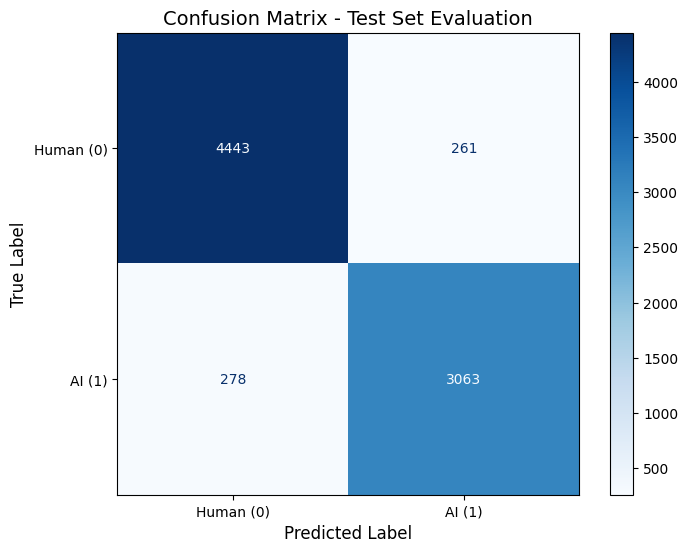

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_predictions)

print("Confusion Matrix:")
print(cm)
print("_" * 40)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human (0)', 'AI (1)'])
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title('Confusion Matrix - Test Set Evaluation', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

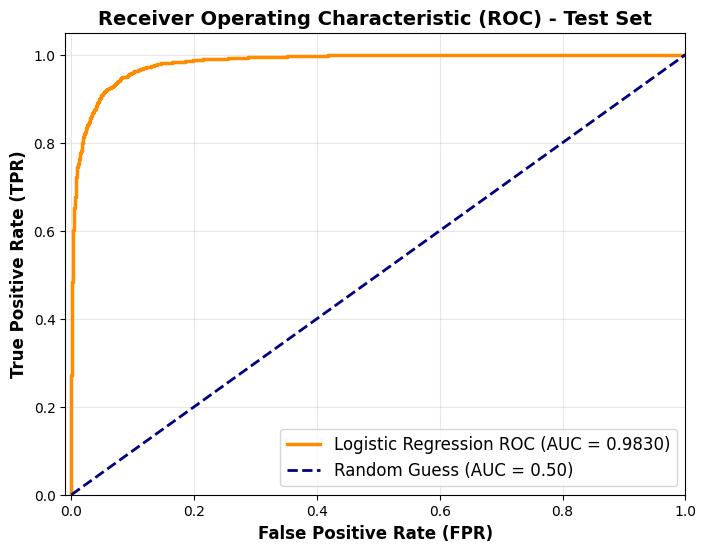

In [22]:
from sklearn.metrics import roc_curve, auc

y_test_probs = final_model.predict_proba(X_test_final)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, 
         label=f'Logistic Regression ROC (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.50)')
 
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC) - Test Set', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.show()